<a href="https://colab.research.google.com/github/JohnUfo/python-and-scikit-tutorial/blob/main/python_and_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [219]:
url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'
from urllib.request import urlretrieve
urlretrieve(url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x7e33b382c4a0>)

In [220]:
import pandas as pd
medical_df = pd.read_csv('medical.csv')
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [221]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [222]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10,6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [223]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# AGE DISTRIBUTION

In [224]:
fig = px.histogram(medical_df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Age Distribution')
fig.update_layout(bargap=0.1)

# BODY MASS INDEX BOX PLOT

In [225]:
fig = px.histogram(medical_df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['red'],
                   title='BMI Distribution')
fig.update_layout(bargap=0.1)

# CHARGES

In [226]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)

# SMOKER

In [227]:
medical_df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [228]:
fig = px.histogram(medical_df,
                   x='smoker',
                   marginal='box',
                   color='sex',
                  #  color_discrete_sequence=['green', 'grey'],
                   title='Smoker')
fig.update_layout(bargap=0.1)

# Age vs Charges

In [229]:
fig = px.scatter(medical_df,
                 x='age',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='Age vs Charges')
fig.update_traces(marker_size=5)

In [230]:
fig = px.scatter(
    medical_df,
    x='bmi',
    y='charges',
    color='smoker',
    opacity=0.8,
    hover_data=['sex'],
    title='BMI vs Charges')
fig.update_traces(marker_size=5)

# Age vs Charges (Split by Children)

In [231]:
fig = px.scatter(medical_df,
                 x='age',
                 y='charges',
                 color='smoker',
                 facet_col='children',
                 opacity=0.7,
                 hover_data=['sex', 'bmi'],
                 title='Age vs Charges (Split by Children)')

fig.update_traces(marker_size=5)
fig.update_yaxes(dtick=5000)

# Correlation

In [232]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306476)

In [233]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362895)

In [234]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790478)

In [235]:
# smoker_values = {'no':0, 'yes':1}
# medical_df.smoker = medical_df.smoker.map(smoker_values)

In [236]:
# medical_df.charges.corr(medical_df.smoker)

In [237]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [238]:
px.scatter(
    medical_df,
    x='age',
    y='age'
)

# Correlation Matrix
 The result of `.corr` is called a correlation matrix and is often visualized using a heatmap.



Text(0.5, 1.0, 'Correlation Matrix')

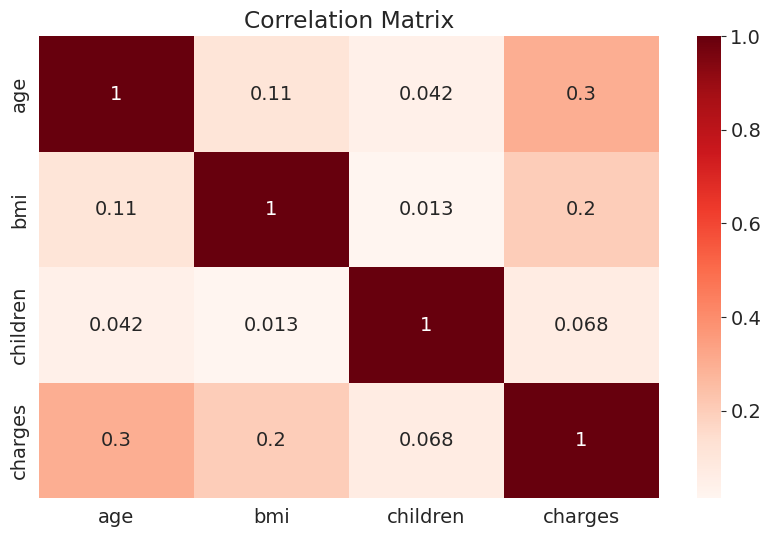

In [239]:
sns.heatmap(medical_df.corr(numeric_only=True),
            cmap='Reds',
            annot=True
)
plt.title('Correlation Matrix')

In [241]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

<Axes: title={'center': 'Age vs Charges'}, xlabel='age', ylabel='charges'>

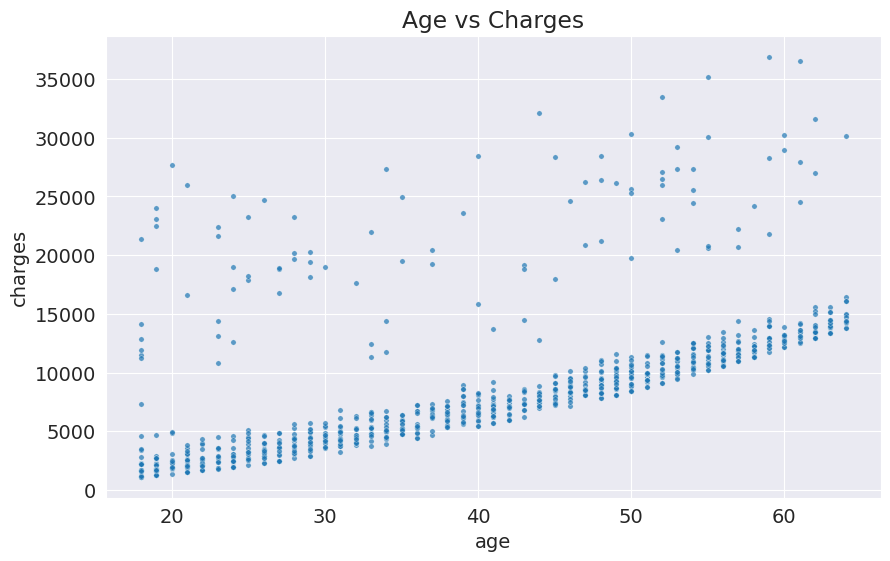

In [242]:
plt.title('Age vs Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges',alpha=0.7,s=15)

# Helper function  `estimate_charges`



In [243]:
def estimate_charges(age,w,b):
  return w * age + b

In [245]:
w = 50
b = 100

In [255]:
ages = non_smoker_df.age
print(ages.head())

1    18
2    28
3    33
4    32
5    31
Name: age, dtype: int64


In [259]:
estimated_charges=estimate_charges(ages,w,b)
print(estimated_charges.head())

1    1000
2    1500
3    1750
4    1700
5    1650
Name: age, dtype: int64


In [261]:
non_smoker_df.charges

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


Text(0, 0.5, 'Estimated Charges')

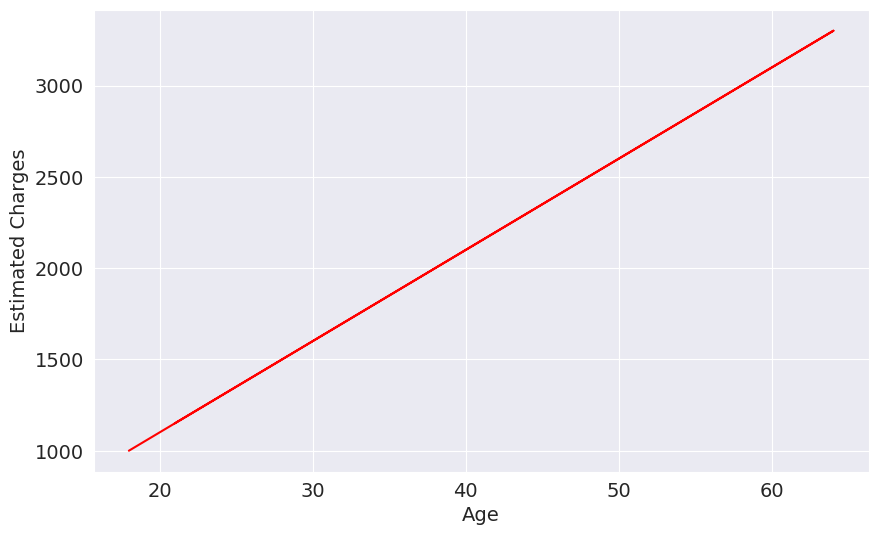

In [264]:
plt.plot(ages,estimated_charges,'r-')
plt.xlabel('Age')
plt.ylabel('Estimated Charges')

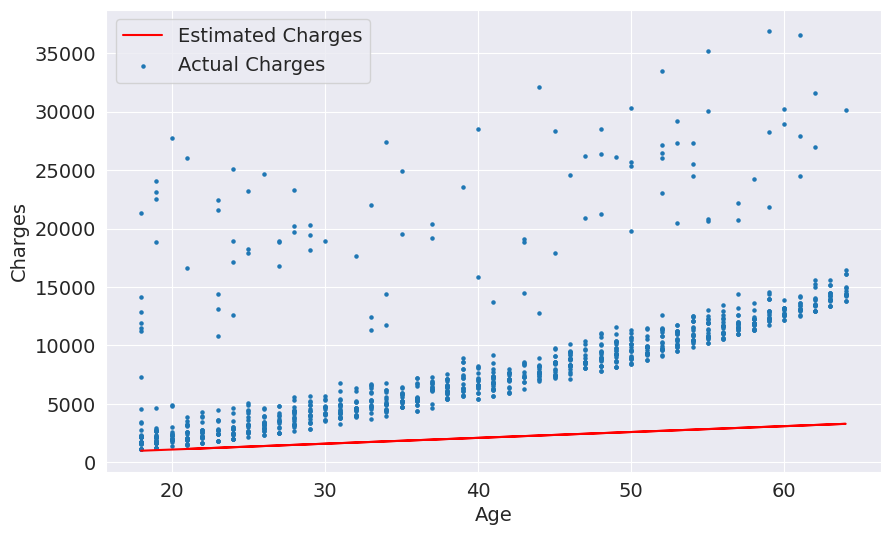

In [274]:
target = non_smoker_df.charges

plt.plot(ages,estimated_charges,'r')
plt.scatter(ages,target,s=5)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimated Charges','Actual Charges'])